# Setup & Load Data

In [1]:
# @title Imports & Setup
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve, auc, precision_recall_curve
from scipy.stats import uniform, randint
from sklearn import set_config
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, classification_report
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer

# Models
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Ensure transformers output pandas DataFrames for easy tracing
set_config(transform_output="pandas")

In [2]:

# @title Load Data
from google.colab import drive
drive.mount("/content/drive", force_remount=True)

df = pd.read_excel('/content/drive/MyDrive/DS102/Dataset/Credit Risk Dataset.xlsx')
df.head()

Mounted at /content/drive


,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,...,city_latitude,city_longitude,employment_type,loan_term_months,loan_to_income_ratio,other_debt,debt_to_income_ratio,open_accounts,credit_utilization_ratio,past_delinquencies
0,CUST_00001,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,...,43.6532,-79.3832,Self-employed,36,0.593220,8402.453850,0.735635,14,0.495557,0
1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,...,43.6532,-79.3832,Full-time,36,0.104167,1607.802794,0.271646,10,0.585436,3
2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,...,51.6214,-3.9436,Full-time,36,0.572917,2760.505633,0.860469,14,0.750732,0
3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,...,49.2827,-123.1207,Part-time,12,0.534351,7155.286150,0.643592,15,0.379333,0
4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,...,42.8864,-78.8784,Part-time,36,0.643382,15626.153439,0.930628,4,0.228103,0


# Feature Engineering & Preprocessing

In [ ]:
# @title Custom Transformers

# 1: Xóa các cột không cần thiết ---
class ColumnDropper(BaseEstimator, TransformerMixin):
    def __init__(self, cols_to_drop):
        self.cols_to_drop = cols_to_drop

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        # Trả về DataFrame đã xóa cột
        return X.drop(columns=self.cols_to_drop, errors='ignore')

# 2: Điền khuyết theo nhóm (Logic của riêng bạn) ---
class CustomGroupImputer(BaseEstimator, TransformerMixin):
    def __init__(self):
        # Nơi lưu trữ các giá trị tính toán từ tập Train
        self.emp_medians_ = {}
        self.int_medians_ = {}
        self.global_emp_median_ = 0
        self.global_int_median_ = 0

    def fit(self, X, y=None):
        # Chỉ TÍNH TOÁN các giá trị Median trên tập dữ liệu được fit (Tập Train)
        X_temp = X.copy()

        # 1. Tính Median cho person_emp_length theo age_group
        X_temp['age_group'] = pd.cut(X_temp['person_age'], bins=[18, 25, 35, 45, 60, 100])
        self.emp_medians_ = X_temp.groupby('age_group', observed=True)['person_emp_length'].median().to_dict()
        self.global_emp_median_ = X_temp['person_emp_length'].median()

        # 2. Tính Median cho loan_int_rate theo loan_grade và loan_term_months
        self.int_medians_ = X_temp.groupby(['loan_grade', 'loan_term_months'])['loan_int_rate'].median().to_dict()
        self.global_int_median_ = X_temp['loan_int_rate'].median()

        return self

    def transform(self, X):
        # ÁP DỤNG các giá trị đã học vào dữ liệu
        X_out = X.copy()

        # 1. Điền khuyết person_emp_length
        # 1.1. Thất nghiệp -> 0
        unemployed_mask = (X_out['person_emp_length'].isna()) & (X_out['employment_type'] == 'Unemployed')
        X_out.loc[unemployed_mask, 'person_emp_length'] = 0

        # 1.2. Điền theo median của nhóm tuổi
        X_out['age_group'] = pd.cut(X_out['person_age'], bins=[18, 25, 35, 45, 60, 100])
        X_out['emp_median'] = X_out['age_group'].map(self.emp_medians_)
        X_out['person_emp_length'] = X_out['person_emp_length'].fillna(X_out['emp_median'])
        # Nếu vẫn còn NaN (do tập Test có nhóm chưa xuất hiện ở Train), điền bằng Global Median
        X_out['person_emp_length'] = X_out['person_emp_length'].fillna(self.global_emp_median_)
        X_out.drop(columns=['age_group', 'emp_median'], inplace=True)

        # 2. Điền khuyết loan_int_rate
        # Map giá trị bằng multi-index
        mapped_int_medians = X_out.set_index(['loan_grade', 'loan_term_months']).index.map(self.int_medians_)
        X_out['loan_int_rate'] = X_out['loan_int_rate'].fillna(pd.Series(mapped_int_medians, index=X_out.index))
        X_out['loan_int_rate'] = X_out['loan_int_rate'].fillna(self.global_int_median_) # Backup

        return X_out

In [4]:
# Lọc bỏ các dòng dữ liệu vô lý
df = df[df['person_age'] <= 100]
df = df[df['person_emp_length'] <= 60]

TARGET = 'loan_status'
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Lần 1: Tách 70% Train, 30% cho Test & Eval
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Lần 2: Tách 30% còn lại thành 20% Test và 10% Eval
X_test, X_eval, y_test, y_eval = train_test_split(X_temp, y_temp, test_size=1/3, random_state=42, stratify=y_temp)

In [ ]:
# @title Preprocessing Pipeline

# Danh sách cột cần xóa
cols_to_drop = ['client_ID', 'city', 'state', 'country', 'city_latitude', 'city_longitude',
                'cb_person_cred_hist_length', 'other_debt']

# Định nghĩa hàm Log Transform xử lý an toàn
log_transformer = FunctionTransformer(np.log1p, feature_names_out='one-to-one')

# --- Nhánh cho biến Số (Numerical) ---
num_pipeline_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), # Backup điền khuyết cho các cột số khác
    ('log_transform', log_transformer),
    ('scaler', StandardScaler())
])

num_pipeline_tree = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log_transform', log_transformer)
])

# --- Nhánh cho biến Phân loại (Categorical) ---
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# --- Gom nhánh bằng ColumnTransformer ---
preprocessor_lr = ColumnTransformer([
    ('num', num_pipeline_lr, make_column_selector(dtype_include=np.number)),
    ('cat', cat_pipeline, make_column_selector(dtype_exclude=np.number))
])

preprocessor_tree = ColumnTransformer([
    ('num', num_pipeline_tree, make_column_selector(dtype_include=np.number)),
    ('cat', cat_pipeline, make_column_selector(dtype_exclude=np.number))
])

# --- ĐÓNG GÓI THÀNH PIPELINE CHUẨN BỊ CHO TRAINING ---
data_prep_pipeline_lr = Pipeline([
    ('drop_cols', ColumnDropper(cols_to_drop)),
    ('group_imputer', CustomGroupImputer()),
    ('preprocessing', preprocessor_lr)
])

data_prep_pipeline_tree = Pipeline([
    ('drop_cols', ColumnDropper(cols_to_drop)),
    ('group_imputer', CustomGroupImputer()),
    ('preprocessing', preprocessor_tree)
])

# Training Model & Evaluation

## Training Default

In [7]:
# @title Support Function
def evaluate_model(name, model_pipeline, X_train, y_train, X_test, y_test):
    """Hàm helper để train và in kết quả đánh giá"""
    print(f"\n===== {name.upper()} =====")

    # Huấn luyện
    model_pipeline.fit(X_train, y_train)

    # Dự đoán
    y_pred = model_pipeline.predict(X_test)
    y_prob = model_pipeline.predict_proba(X_test)[:, 1]

    # In báo cáo
    print(f"AUC Score: {roc_auc_score(y_test, y_prob):.4f}")
    print(classification_report(y_test, y_pred))

    return model_pipeline

In [ ]:
# @title Training
# Logistic Regression
log_pipeline = Pipeline([
    ('prep', data_prep_pipeline_lr),
    ('model', LogisticRegression())
])
trained_log = evaluate_model("Logistic Regression", log_pipeline, X_train, y_train, X_test, y_test)

# XGBoost
xgb_pipeline = Pipeline([
    ('prep', data_prep_pipeline_tree),
    ('model', XGBClassifier(eval_metric='logloss', scale_pos_weight=3.6)) # Cân bằng biến mục tiêu
])
trained_xgb = evaluate_model("XGBoost", xgb_pipeline, X_train, y_train, X_test, y_test)

# LightGBM
lgb_pipeline = Pipeline([
    ('prep', data_prep_pipeline_tree),
    ('model', LGBMClassifier(verbose=-1, is_unbalance=True)) # Cân bằng biến mục tiêu
])
trained_lgb = evaluate_model("LightGBM", lgb_pipeline, X_train, y_train, X_test, y_test)


===== LOGISTIC REGRESSION =====
AUC Score: 0.8876
              precision    recall  f1-score   support

           0       0.90      0.95      0.92      4971
           1       0.78      0.60      0.68      1365

    accuracy                           0.88      6336
   macro avg       0.84      0.78      0.80      6336
weighted avg       0.87      0.88      0.87      6336


===== XGBOOST =====
AUC Score: 0.9471
              precision    recall  f1-score   support

           0       0.94      0.97      0.95      4971
           1       0.86      0.78      0.82      1365

    accuracy                           0.93      6336
   macro avg       0.90      0.87      0.89      6336
weighted avg       0.92      0.93      0.92      6336


===== LIGHTGBM =====
AUC Score: 0.9460
              precision    recall  f1-score   support

           0       0.94      0.96      0.95      4971
           1       0.85      0.77      0.81      1365

    accuracy                           0.92      633

## Training With Hyperparameters

In [ ]:
# @title Threshold tuning

def evaluate_and_find_threshold(model_name, best_model, X_eval, y_eval, X_test, y_test, beta=2):
    print(f"{'='*60}")
    print(f"ĐÁNH GIÁ MÔ HÌNH: {model_name.upper()}")
    print(f"{'='*60}")

    # 1: TÌM NGƯỠNG CẮT TỐI ƯU TRÊN TẬP EVAL (VALIDATION)
    y_eval_probs = best_model.predict_proba(X_eval)[:, 1]
    precisions, recalls, thresholds = precision_recall_curve(y_eval, y_eval_probs)

    # Tính F-beta score (Mặc định beta=2)
    fbeta_scores = (1 + beta**2) * (precisions * recalls) / ((beta**2 * precisions) + recalls + 1e-8)
    best_idx = np.argmax(fbeta_scores[:-1])
    best_threshold = thresholds[best_idx]
    best_fbeta = fbeta_scores[best_idx]

    print(f"THRESHOLD OPTIMIZATION (Tập Eval):")
    print(f" - Ngưỡng tối ưu (Best Threshold): {best_threshold:.4f}")
    print(f" - Max F{beta}-Score đạt được:      {best_fbeta:.4f}\n")

    # 2: ĐÁNH GIÁ TRÊN TẬP TEST & VẼ BIỂU ĐỒ
    y_test_probs = best_model.predict_proba(X_test)[:, 1]
    y_test_pred = (y_test_probs >= best_threshold).astype(int)

    # Báo cáo điểm số
    auc_score = roc_auc_score(y_test, y_test_probs)
    print(f"Kết quả trên tập test:")
    print(f" - ROC AUC Score: {auc_score:.4f}\n")
    print("Classification Report:")
    print(classification_report(y_test, y_test_pred))

    # Tạo subplot 1 hàng, 2 cột để vẽ 2 biểu đồ cạnh nhau
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # --- Biểu đồ 1: Confusion Matrix ---
    cm = confusion_matrix(y_test, y_test_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default (0)', 'Default (1)'])
    disp.plot(cmap='Blues', ax=axes[0], values_format='d', colorbar=False)
    axes[0].set_title(f'Confusion Matrix\n(Threshold: {best_threshold:.4f})')

    # --- Biểu đồ 2: ROC Curve ---
    fpr, tpr, _ = roc_curve(y_test, y_test_probs)
    roc_auc_val = auc(fpr, tpr)

    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc_val:.4f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Đường random guess
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'ROC Curve - {model_name}')
    axes[1].legend(loc="lower right")

    # Hiển thị
    plt.tight_layout()
    plt.show()
    print("\n")

    return best_threshold

Đang tiến hành Tuning cho Logistic Regression
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Tham số tốt nhất cho Logistic Regression: {'model__C': np.float64(4.468327528535911), 'model__penalty': 'l1', 'model__solver': 'liblinear'}
ĐÁNH GIÁ MÔ HÌNH: LOGISTIC REGRESSION
THRESHOLD OPTIMIZATION (Tập Eval):
 - Ngưỡng tối ưu (Best Threshold): 0.4282
 - Max F2-Score đạt được:      0.7327

Kết quả trên tập test:
 - ROC AUC Score: 0.8902

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.77      0.85      4971
           1       0.50      0.83      0.63      1365

    accuracy                           0.79      6336
   macro avg       0.72      0.80      0.74      6336
weighted avg       0.85      0.79      0.80      6336



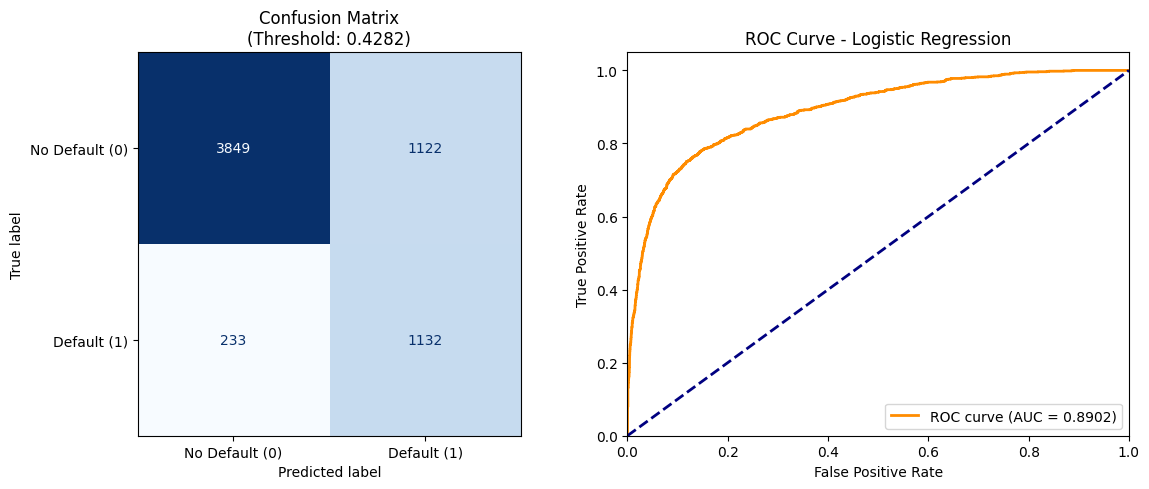



Đã lưu mô hình tại: model_logistic_regression.pkl

Đang tiến hành Tuning cho XGBoost
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Tham số tốt nhất cho XGBoost: {'model__learning_rate': np.float64(0.05680559213273095), 'model__max_depth': 5, 'model__n_estimators': 314}
ĐÁNH GIÁ MÔ HÌNH: XGBOOST
THRESHOLD OPTIMIZATION (Tập Eval):
 - Ngưỡng tối ưu (Best Threshold): 0.3720
 - Max F2-Score đạt được:      0.8032

Kết quả trên tập test:
 - ROC AUC Score: 0.9476

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.88      0.92      4971
           1       0.67      0.86      0.75      1365

    accuracy                           0.88      6336
   macro avg       0.81      0.87      0.84      6336
weighted avg       0.90      0.88      0.88      6336



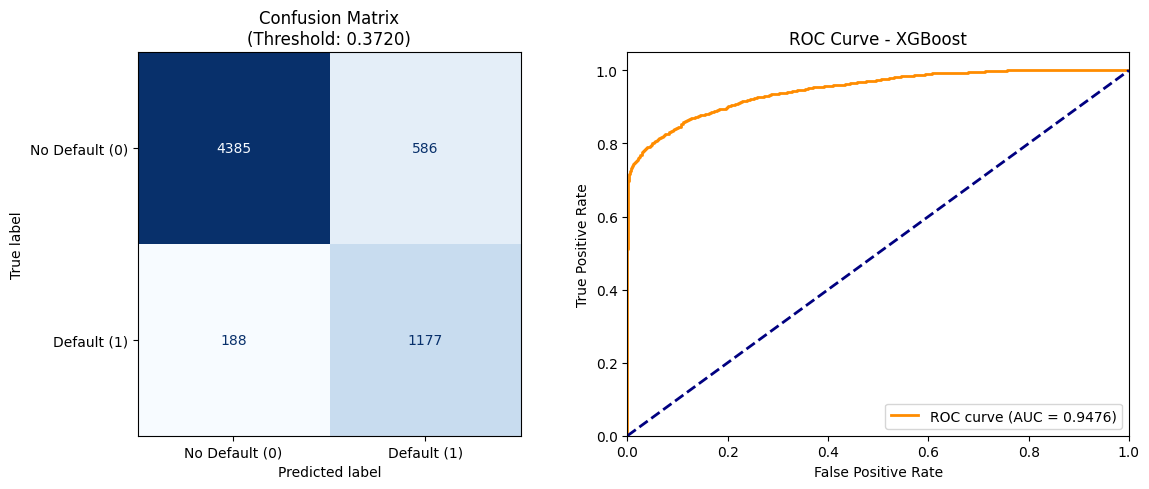



Đã lưu mô hình tại: model_xgboost.pkl

Đang tiến hành Tuning cho LightGBM
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Tham số tốt nhất cho LightGBM: {'model__learning_rate': np.float64(0.05680559213273095), 'model__n_estimators': 314, 'model__num_leaves': 20}
ĐÁNH GIÁ MÔ HÌNH: LIGHTGBM
THRESHOLD OPTIMIZATION (Tập Eval):
 - Ngưỡng tối ưu (Best Threshold): 0.4109
 - Max F2-Score đạt được:      0.8050

Kết quả trên tập test:
 - ROC AUC Score: 0.9477

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.93      0.94      4971
           1       0.77      0.82      0.80      1365

    accuracy                           0.91      6336
   macro avg       0.86      0.88      0.87      6336
weighted avg       0.91      0.91      0.91      6336



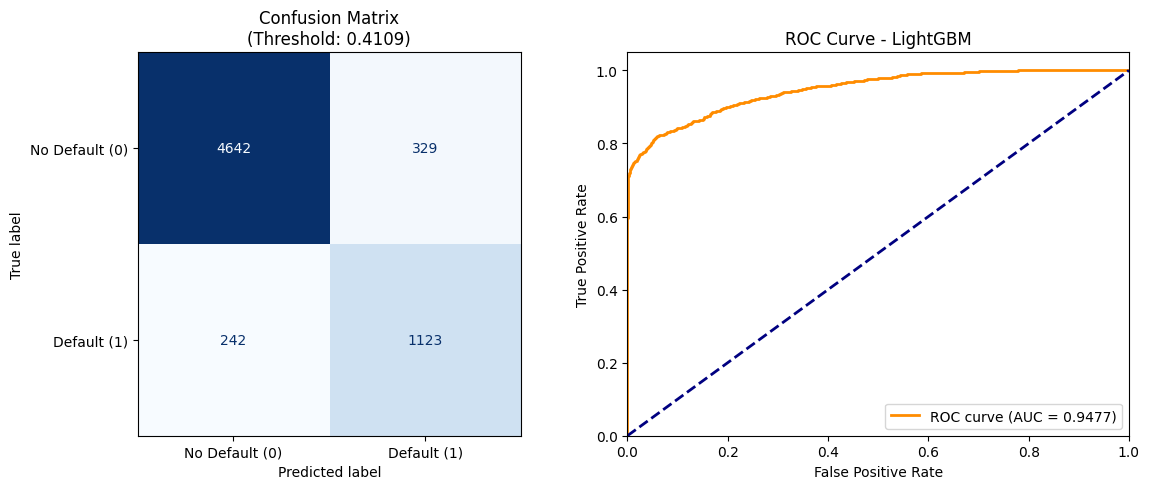



Đã lưu mô hình tại: model_lightgbm.pkl



In [ ]:
# @title Training
# Tính scale_pos_weight cho dữ liệu mất cân bằng (Dùng cho XGBoost)
neg_class_count = (y_train == 0).sum()
pos_class_count = (y_train == 1).sum()
spw_value = neg_class_count / pos_class_count

# 1. Khai báo Dictionary cấu hình cho các Models
models_config = {
    'Logistic Regression': {
        'pipeline': Pipeline([
            ('prep', data_prep_pipeline_lr),
            ('model', LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42))
        ]),
        'params': [
            {
                'model__solver': ['liblinear'],
                'model__penalty': ['l1', 'l2'],
                'model__C': uniform(loc=0.01, scale=10)
            },
            {
                'model__solver': ['saga'],
                'model__penalty': ['elasticnet'],
                'model__l1_ratio': uniform(0, 1),
                'model__C': uniform(loc=0.01, scale=10)
            }
        ]
    },
    'XGBoost': {
        'pipeline': Pipeline([
            ('prep', data_prep_pipeline_tree),
            ('model', XGBClassifier(eval_metric='logloss', scale_pos_weight=spw_value, random_state=42))
        ]),
        'params': {
            'model__n_estimators': randint(100, 500),
            'model__max_depth': randint(3, 10),
            'model__learning_rate': uniform(0.01, 0.3)
        }
    },
    'LightGBM': {
        'pipeline': Pipeline([
            ('prep', data_prep_pipeline_tree),
            ('model', LGBMClassifier(verbose=-1, is_unbalance=True, random_state=42))
        ]),
        'params': {
            'model__n_estimators': randint(100, 500),
            'model__num_leaves': randint(10, 50),
            'model__learning_rate': uniform(0.01, 0.3)
        }
    }
}

# 2. Vòng lặp Tuning, Evaluation và Lưu Model
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
trained_models = {}
optimized_thresholds = {}

for name, config in models_config.items():
    print(f"Đang tiến hành Tuning cho {name}")

    # Khởi tạo RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=config['pipeline'],
        param_distributions=config['params'],
        n_iter=10,
        scoring='roc_auc',  # Tối ưu ROC AUC trong quá trình cross-validation
        cv=cv_strategy,
        n_jobs=-1,          # Sử dụng toàn bộ core CPU để chạy nhanh hơn
        random_state=42,
        verbose=1
    )

    # Bắt đầu Training (Fit tự động xử lý cả Data Prep và Model Training)
    random_search.fit(X_train, y_train)
    best_model_pipeline = random_search.best_estimator_

    print(f"Tham số tốt nhất cho {name}: {random_search.best_params_}")

    # Đánh giá và tìm Threshold
    best_thresh = evaluate_and_find_threshold(
        model_name=name,
        best_model=best_model_pipeline,
        X_eval=X_eval, y_eval=y_eval,
        X_test=X_test, y_test=y_test,
        beta=2 # Tối ưu hóa cho F2-Score
    )

    # Lưu lại kết quả vào biến môi trường
    trained_models[name] = best_model_pipeline
    optimized_thresholds[name] = best_thresh

    # Lưu file model
    filename = f"model_{name.replace(' ', '_').lower()}.pkl"
    joblib.dump(best_model_pipeline, filename)
    print(f"Đã lưu mô hình tại: {filename}\n")

 # Feature Importance & Explainability

In [ ]:
import shap
from sklearn.inspection import permutation_importance

def explain_model(model_name, best_model_pipeline, X_test, y_test):
    print(f"{'='*70}")
    print(f"MODEL EXPLAINABILITY & FEATURE IMPORTANCE: {model_name.upper()}")
    print(f"{'='*70}")

    # 1: TRÍCH XUẤT DỮ LIỆU ĐÃ QUA TIỀN XỬ LÝ & MODEL THÔ
    # Để chạy SHAP và Built-in Importance, biến đổi (Scale, Impute, OHE...)
    model = best_model_pipeline.named_steps['model']

    X_test_processed = X_test.copy()
    # Chạy dữ liệu qua tất cả các bước ngoại trừ model cuối cùng
    for name, step in best_model_pipeline.steps[:-1]:
        X_test_processed = step.transform(X_test_processed)

    # Lấy tên các features sau khi đã xử lý
    features_out = X_test_processed.columns

    # 1. BUILT-IN FEATURE IMPORTANCE (Mô hình tự đánh giá)
    plt.figure(figsize=(10, 6))
    if hasattr(model, 'feature_importances_'):
        # Dành cho Tree-based models (XGBoost, LightGBM)
        importances = model.feature_importances_
        indices = np.argsort(importances)[-15:] # Lấy top 15

        plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
        plt.yticks(range(len(indices)), [features_out[i] for i in indices])
        plt.title(f'1. Top 15 Built-in Feature Importance - {model_name}')

    elif hasattr(model, 'coef_'):
        # Dành cho Logistic Regression (Dựa trên độ lớn của Coefficients)
        importances = model.coef_[0]
        indices = np.argsort(np.abs(importances))[-15:] # Sắp xếp theo giá trị tuyệt đối

        # Đỏ cho trọng số âm (giảm rủi ro), Xanh cho trọng số dương (tăng rủi ro vỡ nợ)
        colors = ['red' if importances[i] < 0 else 'green' for i in indices]
        plt.barh(range(len(indices)), importances[indices], align='center', color=colors)
        plt.yticks(range(len(indices)), [features_out[i] for i in indices])
        plt.title(f'1. Top 15 Coefficients Magnitude - {model_name}\n(Xanh: Positive, Đỏ: Negative)')

    plt.xlabel('Importance / Coefficient Value')
    plt.tight_layout()
    plt.show()

    # 2. PERMUTATION IMPORTANCE (Đánh giá trên tập gốc)
    print("Đang tính toán Permutation Importance")
    # Lưu ý: Chạy Permutation trên TOÀN BỘ pipeline bằng dữ liệu X_test thô ban đầu.
    # Nhờ vậy ta xem được ảnh hưởng của các cột gốc (chưa bị phân mảnh bởi One-hot)
    perm_importance = permutation_importance(
        best_model_pipeline, X_test, y_test,
        n_repeats=5, random_state=42, n_jobs=-1, scoring='roc_auc'
    )

    # Lấy Top 10 features gốc quan trọng nhất
    sorted_idx = perm_importance.importances_mean.argsort()[-10:]

    plt.figure(figsize=(10, 6))
    plt.boxplot(
        perm_importance.importances[sorted_idx].T,
        vert=False,
        labels=X_test.columns[sorted_idx],
        patch_artist=True,
        boxprops=dict(facecolor='lightgreen', color='green')
    )
    plt.title(f"2. Permutation Importance (ROC AUC) - {model_name}\n(Mức độ giảm điểm AUC khi xáo trộn Feature Gốc)")
    plt.tight_layout()
    plt.show()

    # 3. SHAP VALUES (Sức mạnh giải thích chuyên sâu)
    print("Đang tính toán SHAP values")
    # SHAP bắt buộc dùng dữ liệu đã qua xử lý và model thô
    shap.initjs() # Khởi tạo JS vẽ các interactive plots sau này

    if model_name in ['XGBoost', 'LightGBM']:
        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_test_processed)

        # Với binary classification ở vài version, shap trả về list [class_0, class_1]
        if isinstance(shap_values, list):
            shap_values_to_plot = shap_values[1]
        else:
            shap_values_to_plot = shap_values

        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values_to_plot, X_test_processed, plot_type="dot", max_display=15, show=False)
        plt.title(f"3. SHAP Summary Plot - {model_name}")
        plt.show()

    elif model_name == 'Logistic Regression':
        # LinearExplainer hoạt động tốt nhất khi có background dataset
        background = shap.maskers.Independent(X_test_processed, max_samples=100)
        explainer = shap.LinearExplainer(model, background)
        shap_values = explainer.shap_values(X_test_processed)

        plt.figure(figsize=(10, 6))
        shap.summary_plot(shap_values, X_test_processed, max_display=15, show=False)
        plt.title(f"3. SHAP Summary Plot - {model_name}")
        plt.show()

    print("\n")

MODEL EXPLAINABILITY & FEATURE IMPORTANCE: LOGISTIC REGRESSION


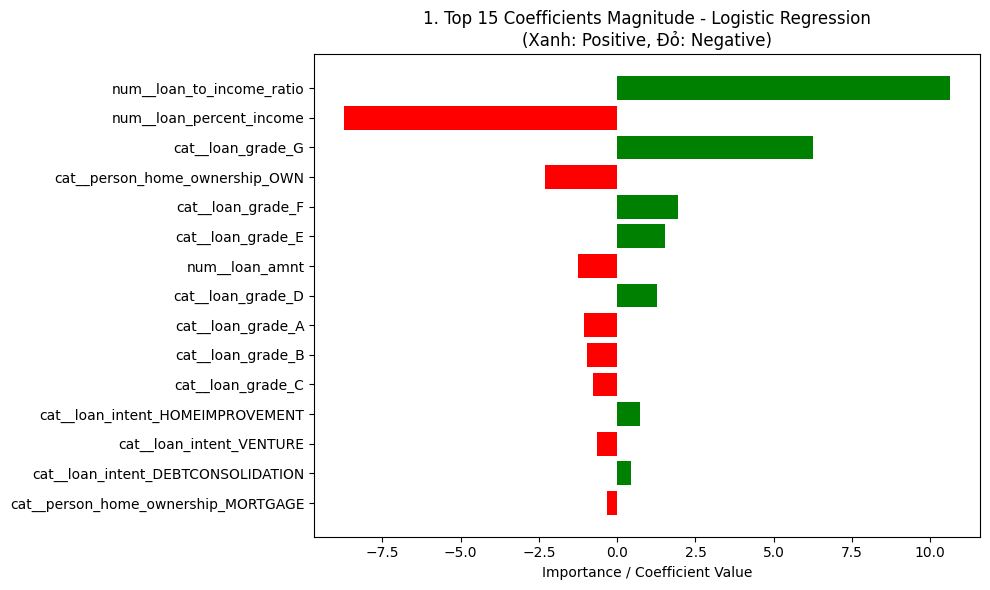

Đang tính toán Permutation Importance


/tmp/ipykernel_6231/3489320794.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


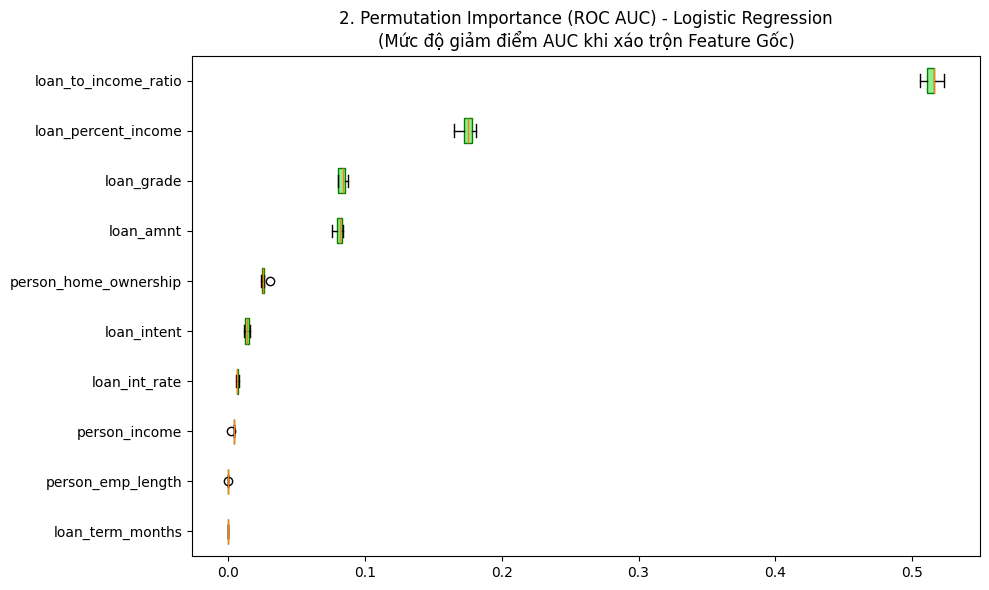

Đang tính toán SHAP values


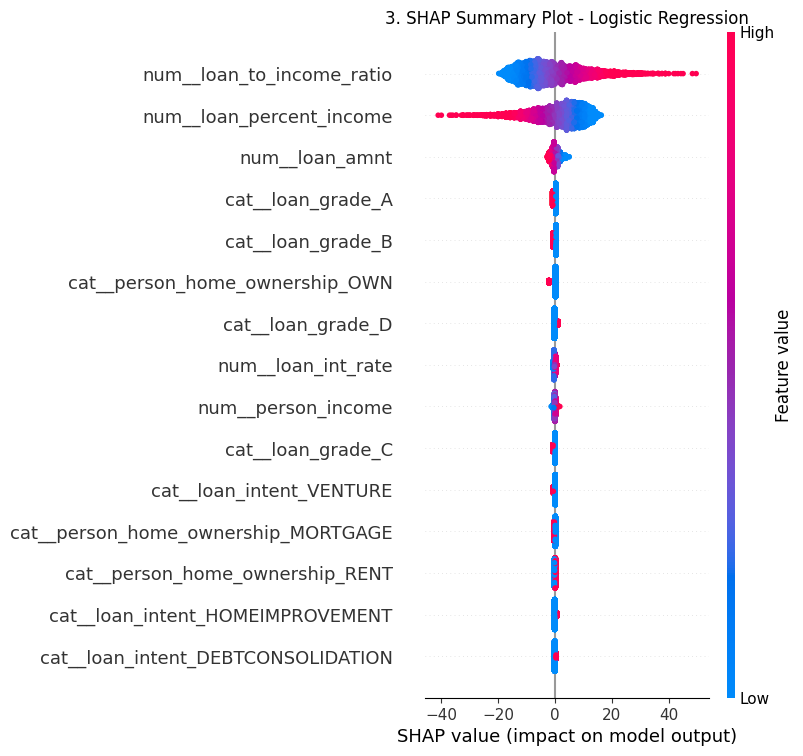



MODEL EXPLAINABILITY & FEATURE IMPORTANCE: XGBOOST


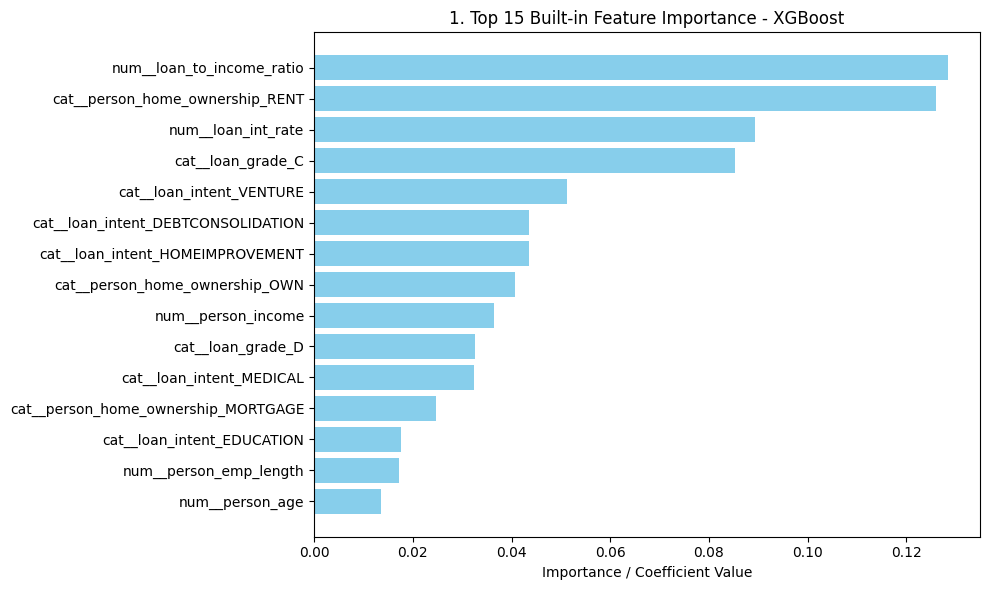

Đang tính toán Permutation Importance


/tmp/ipykernel_6231/3489320794.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


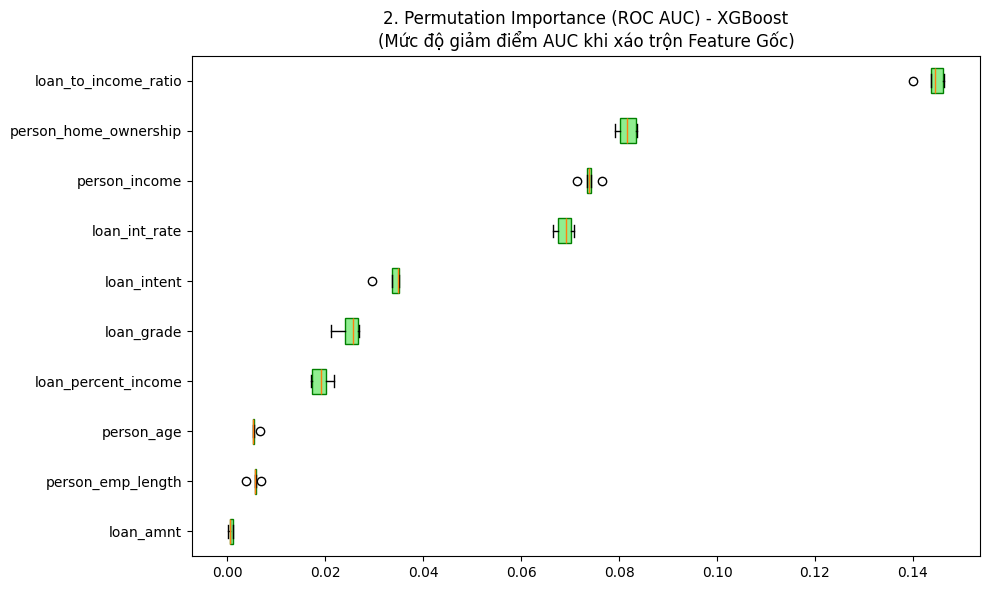

Đang tính toán SHAP values


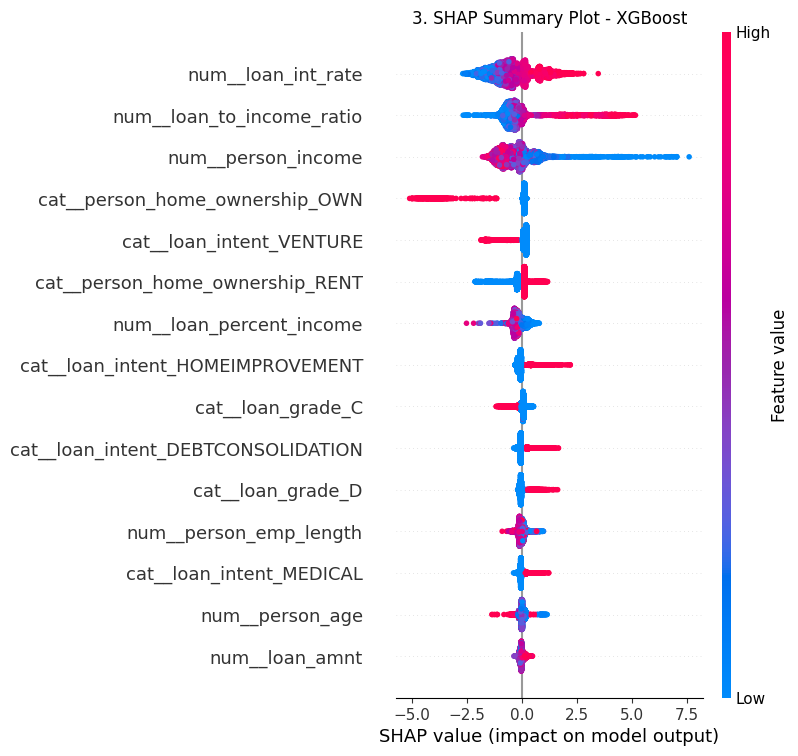



MODEL EXPLAINABILITY & FEATURE IMPORTANCE: LIGHTGBM


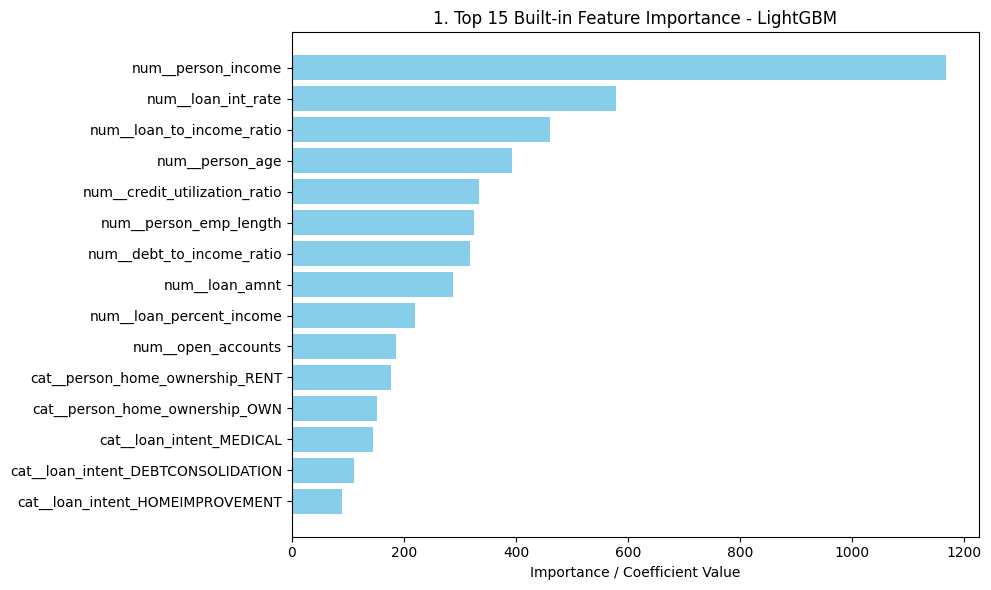

Đang tính toán Permutation Importance


/tmp/ipykernel_6231/3489320794.py:66: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


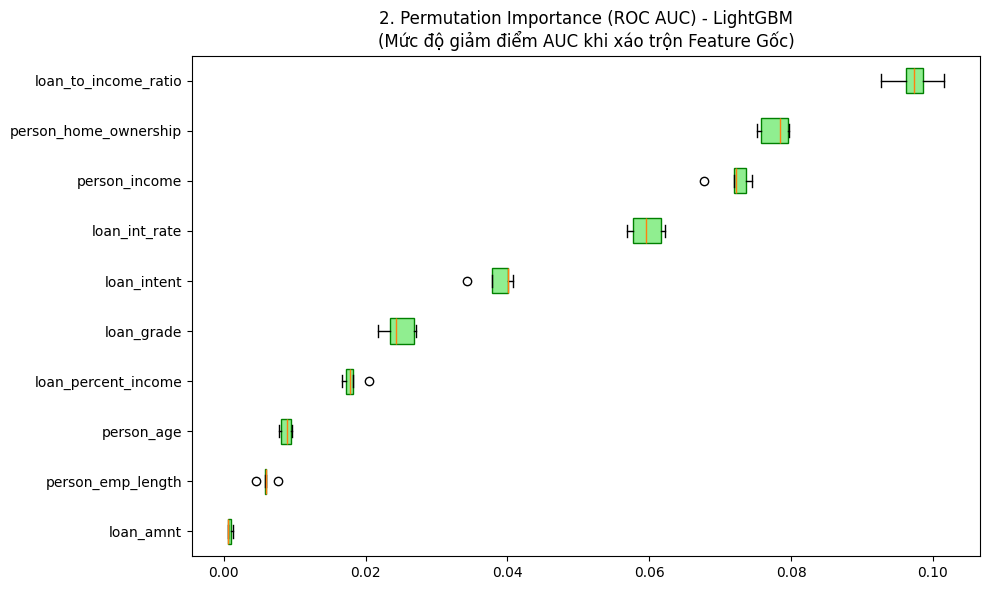

Đang tính toán SHAP values


/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:620: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


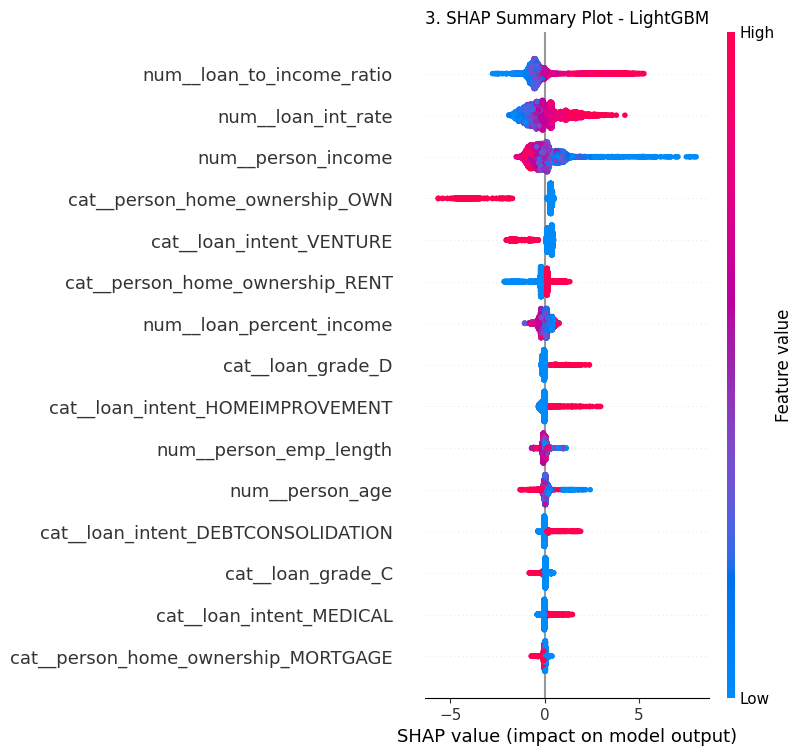

In [24]:
# Gọi hàm giải thích cho từng mô hình đã train
for name, best_pipeline in trained_models.items():
    explain_model(
        model_name=name,
        best_model_pipeline=best_pipeline,
        X_test=X_test,
        y_test=y_test
    )